# Analyse exploratoire : préparation des axes d'analyse

Ce notebook a pour objectif :
- d'explorer le dataset brut,
- d'identifier les colonnes existantes,
- de construire un plan de colonnes,
- de définir trois axes d'analyse (vie personnelle, conditions de travail, satisfaction & implication),
- en vue de préparer les futures analyses sur l'attrition.

---

# 1. Import des librairies

In [2]:
import kagglehub
import pandas as pd
import pyarrow
import numpy as np
import os

# 2. Chargement des données

In [3]:
# 1. Téléchargement du dataset
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("Données téléchargées ici :", path)

# 2. Lister les fichiers
print("\nFichiers disponibles :")
for fichier in os.listdir(path):
    print(" -", fichier)


# 3. Charger le CSV principal
csv_path = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = pd.read_csv(csv_path)

# 4. Afficher un aperçu
print("\nAperçu du dataset :")
print(df.head(2))



Données téléchargées ici : C:\Users\Kemu\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1

Fichiers disponibles :
 - WA_Fn-UseC_-HR-Employee-Attrition.csv

Aperçu du dataset :
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...                         1            80                 0   
1  ...                         4            80                 1   

   TotalWorkingYears  TrainingTimesLastYear WorkLifeBalance  YearsAtCompany  \
0                  8                   

# 3. Exploration générale

### 3.1 Vérification des types

In [4]:
# Affichage des types de données et de la structure du dataframe

display(df.info())
display(df.dtypes)
display(df.describe())
display(df.shape)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

None

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


(1470, 35)

In [5]:
# Afficher liste des colonnes

display(df.columns)

for col in df.columns:
    print(f'\n {col}\n {df[col].unique()}')

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


 Age
 [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]

 Attrition
 ['Yes' 'No']

 BusinessTravel
 ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

 DailyRate
 [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  201 1427  857  933 1181 1395  662 1436  1

### 3.2 Valeurs manquantes

In [6]:
# Detecter
display(df.isnull().mean())

# Vérifie si toutes les colonnes ont 0 valeurs manquantes
if (df.isnull().mean() == 0).all():
    print("Il n'y a aucune valeur manquante")
else:
    print("Il existe des valeurs manquantes dans le dataframe")



Age                         0.0
Attrition                   0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtC

Il n'y a aucune valeur manquante


### 3.3 Doublons

In [7]:
print(df.duplicated())
display(f' la moyenne des doublons est de {df.duplicated().mean()}')

# aucun doublons

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool


' la moyenne des doublons est de 0.0'

### 3.4 Correction des types & nettoyage léger des données 

Les colonnes catégorielles sont converties en type `string` et leurs valeurs sont uniformisées (espaces, majuscules, etc.).
---

In [8]:
# # Colonnes catégorielles
colonne_str = ["Attrition","BusinessTravel","Department","EducationField","Gender","JobRole","MaritalStatus","Over18","OverTime"]

# convertir en string 
df[colonne_str] = df[colonne_str].astype("string")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   string
 2   BusinessTravel            1470 non-null   string
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   string
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   string
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   string
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
# Uniformiser 
df[colonne_str] = df[colonne_str].apply(lambda x:x.str.strip().str.title())


In [10]:
# Verification des categories
for col in colonne_str:
    print(f'\n{col}\n{df[col].unique()}')
   


Attrition
<StringArray>
['Yes', 'No']
Length: 2, dtype: string

BusinessTravel
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: string

Department
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: string

EducationField
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: string

Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: string

JobRole
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: string

MaritalStatus
<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: string

Over18
<StringArray>
['Y']
Length: 1, dtype: string

OverTime
<StringArray>


### 3.5 Vérification des colonnes numériques
---

Analyse des valeurs minimales / maximales, des distributions et détection de colonnes constantes.

---

In [11]:
# Les statistiques de base
display(df.describe())

# Colonnnes numeriques
colonne_num = df.select_dtypes(include="number").columns

# Vérification de colonnes numériques spécifiques
display(f'MonthlyIcome min = {df['MonthlyIncome'].min()} max = {df['MonthlyIncome'].max()}')
display(f'PercentSalaryHike min = {df['PercentSalaryHike'].min()} max = {df['PercentSalaryHike'].max()}')

# Détection colonnes numériques constantes
for col in colonne_num :
    if df[col].nunique() == 1:
         print(f"- {col} est constante ({df[col].unique()[0]})")


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


'MonthlyIcome min = 1009 max = 19999'

'PercentSalaryHike min = 11 max = 25'

- EmployeeCount est constante (1)
- StandardHours est constante (80)


<Axes: >

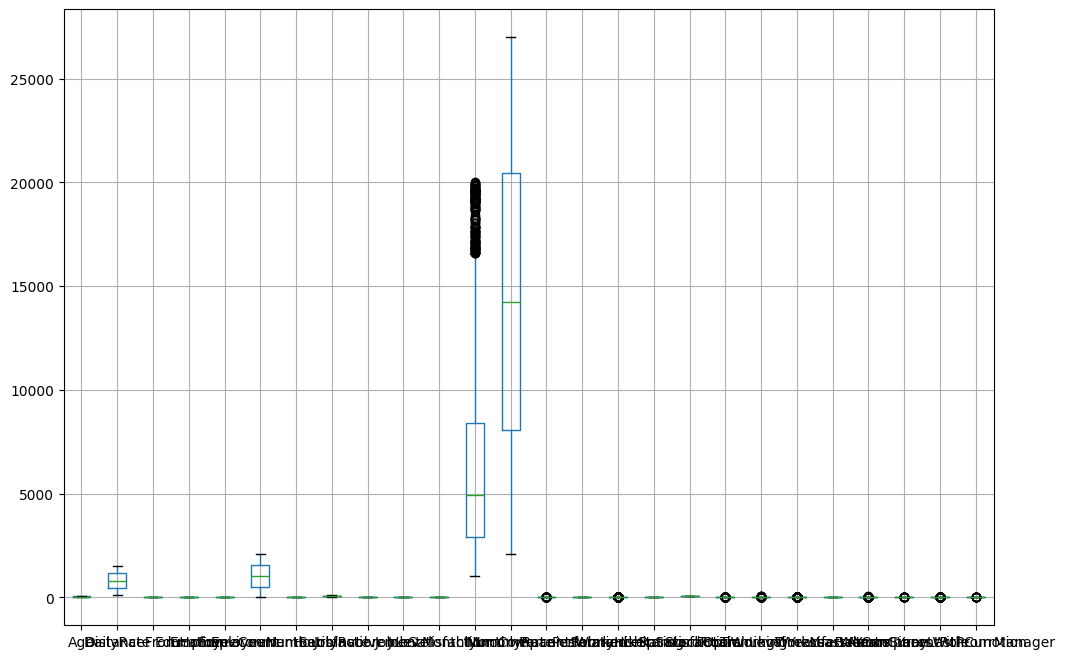

In [12]:
# Visualisation des distributions
df.boxplot(figsize=(12,8))


# 4. Plan de colonnes : préparation des axes
---
Dans cette section, j'analyse les colonnes du dataset afin de les regrouper en trois axes :
- Vie personnelle
- Conditions de travail
- Satisfaction & implication

Ce travail permet de structurer les futures analyses.

Le plan permet également d’identifier les colonnes qui ne seront pas conservées (variables constantes, identifiants, ou attributs hors champ d’analyse). Ces colonnes sont laissées dans le DataFrame nettoyé mais exclues lors de la création des DataFrames d’axe.---


In [17]:
df_plan = pd.read_csv("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/interim/plan_colonnes_done.csv", sep=",")
df_plan.head()

,col_initial,axe,garder
0,Age,Vie personnelle,oui
1,Attrition,Attrition,oui
2,BusinessTravel,Conditions de travail,oui
3,DailyRate,Conditions de travail,non
4,Department,Conditions de travail,oui


# 5. Analyse par axe
---
## Axe: Vie personnelle (Facteurs externes individuels) 
Cet axe regroupe les caractéristiques individuelles qui ne dépendent pas de l’entreprise.
- style de vie
- stabilité personnelle
- parcours éducatif
- situation familiale

Ces variables sont considérées comme des facteurs externes individuels pouvant influencer l'attrition.

---
## Axe : Conditions de travail (Facteurs externes organisationnels) 
Cet axe regroupe les éléments organisationnels contrôlés par l'entreprise :
- salaire
- charge de travail
- rôle occupé
- horaires
- progression interne 
- relation avec le manager
- formation

Ces facteurs peuvent être modifiés par des politiques RH.

---
## Axe : Satisfaction & implication (Facteurs internes psychologiques)
Cet axe représente le ressenti interne du salarié :
- satisfaction au travail
- satisfaction de l’environnement
- satisfaction des relations
- équilibre vie pro / perso
- implication

Cet axe sera analysé comme un facteur explicatif potentiel de l’attrition, puis analysé en lien avec les facteurs externes afin d'identifier les leviers d'amélioration potentienls.




# 6. Sauvegarde du DataFrame nettoyé
---

À cette étape, le dataset a été entièrement nettoyé (correction des types, normalisation des catégories, suppression des colonnes inutiles).  
Nous enregistrons maintenant une version propre et standardisée sous format **Parquet**
afin de l'utiliser dans les notebooks d'analyse par axe.


In [14]:
# Sauvegarder en Parquet df_clean
df_clean = df
df_clean.to_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet", index=False)
